In [1]:
import torchvision 
import torch.nn as nn
import torch 
import torch.nn.functional as F
from torchvision import transforms, models, datasets
from PIL import Image
from torch import optim
device = "cuda" if torch.cuda.is_available() else "cpu"
import cv2,glob,numpy as np,pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
import os
from PIL import Image
import numpy as np
import torch
train_expressions = []
test_expressions = [] 
train_labels = []
test_labels = []
labels = {"angry":0,"disgust":1,"fear":2,"happy":3,"neutral":4,"sad":5,"surprise":6,"suprise":6}

In [3]:
human_face_emotion_dataset_path = "/kaggle/input/datasets/samithsachidanandan/human-face-emotions"

In [4]:
def get_human_face_emotion_dataset(path):
    for file1 in os.listdir(path):
        file2_path = os.path.join(path,file1)
        for file2 in os.listdir(file2_path):
            emotion_label = file2.lower()
            file3_path = os.path.join(file2_path,file2)
            for file3 in os.listdir(file3_path):
                picture_path = os.path.join(file3_path,file3)
                train_expressions.append(picture_path)
                train_labels.append(labels[emotion_label])

In [5]:
get_human_face_emotion_dataset(human_face_emotion_dataset_path)

In [6]:
print(len(train_expressions))
print(len(train_labels))

59099
59099


In [7]:
def get_dataset(path):
    for bark in os.listdir(path):
        r = os.path.join(path,bark)
        #print(r)
        for fire in os.listdir(r):
            new_path = os.path.join(r,fire)
            for ice in os.listdir(new_path):
                updated_path = os.path.join(new_path,ice)
                if bark=="train":
                    train_expressions.append(updated_path)
                    train_labels.append(labels[fire])
                else:
                    test_expressions.append(updated_path)
                    test_labels.append(labels[fire])

In [8]:
fer2013_path = "/kaggle/input/datasets/msambare/fer2013"

In [9]:
get_dataset(fer2013_path)

In [10]:
print(len(train_expressions))
print(len(test_expressions))

87808
7178


In [11]:
def getFANE_dataset(path):
    for file1 in os.listdir(path):
        file2_path = os.path.join(path,file1)
        for emotion_label in os.listdir(file2_path):
            if emotion_label not in labels:
                continue
            emotion_path = os.path.join(file2_path,emotion_label)
            for pic in os.listdir(emotion_path):
                picture_path = os.path.join(emotion_path,pic)
                train_expressions.append(picture_path)
                train_labels.append(labels[emotion_label])

In [12]:
fane_path = "/kaggle/input/datasets/furcifer/fane-facial-expressions-and-emotion-dataset"

In [13]:
getFANE_dataset(fane_path)

In [14]:
print(len(train_expressions))
print(len(test_expressions))

102203
7178


In [15]:
print(train_expressions[0])

/kaggle/input/datasets/samithsachidanandan/human-face-emotions/Data/Fear/22069.png


In [16]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [17]:
from torch.utils.data import DataLoader, Dataset
class FaceExpressionDataset(Dataset):
    def __init__(self,paths,labels,transform = None):
        self.paths = paths 
        self.labels = labels 
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self,index):
        picture_path = self.paths[index]
        try:
            picture = Image.open(picture_path).convert("L")
        except:
            print("Skipping corrupted or missing file:",picture_path)
            picture = Image.new("L",(224,224))
        if self.transform is not None:
            picture = self.transform(picture)
        #picture = np.array(picture)
        #picture = torch.tensor(picture)
        return picture,self.labels[index]

In [18]:
dataset_custom_train = FaceExpressionDataset(train_expressions,train_labels,transform)

In [19]:
dataset_custom_test_original = FaceExpressionDataset(test_expressions,test_labels,transform)

In [20]:
from torch.utils.data import random_split
def index_splitter(n,splits):
    indices = np.arange(n)
    splits = torch.as_tensor(splits)
    splits = (splits*n).long()
    splits = splits/100
    splits = splits.int()
    vestigial_part = n - splits.sum()
    splits[0] += vestigial_part 
    return random_split(indices,splits)

In [21]:
test_indices, val_indices = index_splitter(len(dataset_custom_test_original),[80,20])

from torch.utils.data import Subset 

test_dataset = Subset(dataset_custom_test_original, test_indices.indices)
val_dataset = Subset(dataset_custom_test_original, val_indices.indices)

In [22]:
print(len(test_dataset))
print(len(val_dataset))

5743
1435


In [23]:
def getDistinctLabels(dataset):
    q = {"0":0,"1":0,"2":0,"3":0,"4":0,"5":0,"6":0}
    v = len(dataset)
    for i in range(0,v):
        label = int(dataset[i][1])
        q[str(label)] = q[str(label)] + 1 
    return q

In [24]:
label_frequency = getDistinctLabels(dataset_custom_train)

Skipping corrupted or missing file: /kaggle/input/datasets/furcifer/fane-facial-expressions-and-emotion-dataset/fane_data/happy/happy1283.jpg


In [25]:
print(label_frequency)

{'0': 15917, '1': 1814, '2': 16729, '3': 27576, '4': 6800, '5': 20115, '6': 13252}


In [28]:
label_freq = [0]*7
for lbl in label_frequency:
    label_freq[int(lbl)] = label_frequency[lbl]

In [29]:
print(label_freq)

[15917, 1814, 16729, 27576, 6800, 20115, 13252]


In [30]:
from torch.utils.data import WeightedRandomSampler

class_counts = torch.tensor(label_freq, dtype=torch.float)
class_weights = 1.0 / class_counts

sample_weights = [class_weights[label] for label in dataset_custom_train.labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [31]:
train_loader = DataLoader(dataset_custom_train,batch_size=32,sampler=sampler)
val_loader = DataLoader(val_dataset,batch_size=32)
test_loader = DataLoader(test_dataset,batch_size=32)

In [32]:
def getDistinctLabelsLoader(loader):
    q = {"0":0,"1":0,"2":0,"3":0,"4":0,"5":0,"6":0}
    for x_i, y_i in loader:
        for fire in y_i:
            q[str(int(fire))] = q[str(int(fire))] +1 
    return q 

In [33]:
getDistinctLabelsLoader(train_loader)

Skipping corrupted or missing file: /kaggle/input/datasets/furcifer/fane-facial-expressions-and-emotion-dataset/fane_data/happy/happy1283.jpg


{'0': 14717,
 '1': 14431,
 '2': 14607,
 '3': 14517,
 '4': 14561,
 '5': 14702,
 '6': 14668}

In [34]:
def conv_layer(ni,no,kernel_size,stride=1):
    return nn.Sequential(
        nn.Conv2d(ni,no,kernel_size,stride,padding=1),
        nn.ReLU(),
        nn.BatchNorm2d(no),
        nn.MaxPool2d(2)
    )
class ConvModel(nn.Module):
    def __init__(self,p=0):
        super().__init__()
        self.conv1 = conv_layer(1,32,3)
        self.conv2 = conv_layer(32,64,3)
        self.conv3 = conv_layer(64,128,3)
        self.conv4 = conv_layer(128,256,3)
        dummy_image = torch.zeros(1,1,224,224)
        dummy_feature_size = self.featurizer(dummy_image).shape[1]
        print("dummy feature size:",dummy_feature_size)
        self.fc1 = nn.Linear(dummy_feature_size,128) 
        self.fc2 = nn.Linear(128,7)
        self.p = p
        self.drop = nn.Dropout(self.p)
    def featurizer(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = F.adaptive_avg_pool2d(x, (1,1))
        x = torch.flatten(x, 1)

        return x 
    def classifier(self,x):
        x = self.fc1(x)
        x = F.relu(x)
        if self.p>0:
            x = self.drop(x)
        x = self.fc2(x)
        return x
    def forward(self,x):
        x = self.featurizer(x)
        return self.classifier(x)

In [35]:
model = ConvModel()
multi_loss_fn = nn.CrossEntropyLoss(reduction="mean")
optimizer = optim.Adam(model.parameters(),lr=1e-4, weight_decay=1e-4)

dummy feature size: 256


In [36]:
class StepByStep:
    def __init__(self,model,loss_fn,optimizer):
        self.model = model
        self.loss_fn = loss_fn 
        self.optimizer = optimizer
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model.to(self.device)
        self.train_loader = None
        self.val_loader = None 
        self.test_loader = None
        self.writer = None 
        self.best_model_weights = None
        self.train_losses = [] 
        self.val_losses = [] 
        self.best_val_loss = float("inf")
        self.epoch = 0
        self.total_epochs = 0 
        self.patience = 15 
        self.train_step_fn = self.get_train_step_fn()
        self.val_step_fn = self.get_val_step_fn() 
        self.best_val_accuracy = 0 
    def to(self,device):
        try:
            self.device = device
            self.model.to(self.device)
        except RuntimeError:
            self.device = ("cuda" if torch.cuda.is_available() else "cpu")
            print("Coundn't send to",device,",sending it to",self.device,"instead.")
            self.model.to(self.device) 
    def set_loaders(self,train_loader,val_loader=None):
        self.train_loader = train_loader
        self.val_loader = val_loader 
    def get_accuracy(self,yhat,y,threshold=0.5):
        q = len(yhat)
        softmax_output = F.softmax(yhat,dim=1)
        predictions = torch.argmax(softmax_output,axis=1)
        return predictions 
    def get_train_step_fn(self):
        def perform_train_step_fn(x,y):
            self.model.train()
            yhat = self.model(x)
            loss = self.loss_fn(yhat,y)
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()
            predictions = self.get_accuracy(yhat,y)
            results = predictions==y
            results = results.int().squeeze(0)
            for i in range(len(results)):
                results[i] = results[i].item()
            self.train_accuracy.extend(results)
            return loss.item()
        return perform_train_step_fn
    def get_val_step_fn(self):
        def perform_val_step_fn(x,y):
            self.model.eval()
            yhat = self.model(x)
            loss = self.loss_fn(yhat,y)
            predictions = self.get_accuracy(yhat,y)
            results = predictions==y
            results = results.int().squeeze(0)
            for i in range(0,len(results)):
                results[i] = results[i].item()
            self.val_accuracy.extend(results)
            return loss.item()
        return perform_val_step_fn
    
    def _mini_batch(self,validation=False):
        if validation:
            data_loader = self.val_loader
            step_fn = self.val_step_fn
        else:
            data_loader = self.train_loader
            step_fn = self.train_step_fn
        if data_loader is None:
            return None
        n_batches = len(data_loader)
        mini_batch_losses = [] 
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            mini_batch_loss = step_fn(x_batch,y_batch)
            mini_batch_losses.append(mini_batch_loss)
        loss = np.mean(mini_batch_losses)
        return loss
    def set_seed(self,seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.manual_seed(seed)
        np.random.seed(seed)
    def show_accuracy(self,matchings):
        s = 0 
        for fire in matchings:
            s = s + fire
        s = s/len(matchings)
        s = s *100
        return s
        
    def train(self,n_epochs,seed=42):
        counter = 0 
        self.set_seed(seed)
        starting_epoch = self.epoch
        while self.epoch<starting_epoch+n_epochs:
            self.epoch+=1
            self.train_accuracy = [] 
            self.val_accuracy = []
            print("Epoch:",self.epoch)
            self.total_epochs +=1 
            loss = self._mini_batch(validation=False)
            self.train_losses.append(loss)
            accuracy = self.show_accuracy(self.train_accuracy)
            print("Total training samples checked:",len(self.train_accuracy))
            print("Train accuracy:",accuracy)
            with torch.no_grad():
                val_loss = self._mini_batch(validation=True)
                accuracy = self.show_accuracy(self.val_accuracy)
                self.val_losses.append(val_loss)
                print("Total validation samples checked:",len(self.val_accuracy))
                print("Validation Accuracy",accuracy)
                if accuracy>self.best_val_accuracy:
                    counter = 0 
                    self.best_val_accuracy = accuracy 
                    self.best_model_weights = self.model.state_dict()
                    print("✅Best Model saved from epoch",self.epoch,"with validation accuracy",accuracy)
                else:
                    counter +=1 
                    if counter>self.patience:
                        print("🛑 Early stopping triggered at epoch",self.epoch)
                        break
        self.model.load_state_dict(self.best_model_weights)
    def predict(self,x):
        self.model.eval()
        x_tensor = torch.as_tensor(x).float()
        y_hat_tensor = self.model(x_tensor.to(self.device))
        self.model.train()
        return y_hat_tensor.detach().cpu().numpy()
    def plot_losses(self):
        fig = plt.figure(figsize=(10,4))
        plt.plot(self.train_losses,label="Training Losses",c="b")
        if self.val_loader:
            plt.plot(self.val_losses,label="Validation Losses",c="r")
        plt.yscale("log")
        plt.ylabel("Loss")
        plt.xlabel("Epochs")
        plt.legend()
        plt.tight_layout()
        return fig 

In [37]:
def model_testing(self):
    self.model.eval()
    test_accuracy = [] 
    for x_batch, y_batch in self.test_loader:
        x_batch = x_batch.to(self.device)
        y_batch = y_batch.to(self.device)
        yhat = self.model(x_batch)
        predictions = self.get_accuracy(yhat,y_batch)
        results = predictions == y_batch 
        results = results.int().squeeze(0)
        q = len(results)
        for i in range(0,q):
            results[i] = results[i].item()
        test_accuracy.extend(results)
    testing_accuracy = self.show_accuracy(test_accuracy)
    print("Total test samples checked:",len(test_accuracy))
    print("Test accuracy:",testing_accuracy)
setattr(StepByStep,'model_testing',model_testing)

In [38]:
sbs_custom = StepByStep(model,multi_loss_fn,optimizer)
sbs_custom.set_loaders(train_loader,val_loader)
sbs_custom.test_loader = test_loader

In [39]:
sbs_custom.train(33)

Epoch: 1
Skipping corrupted or missing file: /kaggle/input/datasets/furcifer/fane-facial-expressions-and-emotion-dataset/fane_data/happy/happy1283.jpg
Total training samples checked: 102203
Train accuracy: tensor(35.9441, device='cuda:0')
Total validation samples checked: 1435
Validation Accuracy tensor(39.7909, device='cuda:0')
✅Best Model saved from epoch 1 with validation accuracy tensor(39.7909, device='cuda:0')
Epoch: 2
Skipping corrupted or missing file: /kaggle/input/datasets/furcifer/fane-facial-expressions-and-emotion-dataset/fane_data/happy/happy1283.jpg
Total training samples checked: 102203
Train accuracy: tensor(52.6169, device='cuda:0')
Total validation samples checked: 1435
Validation Accuracy tensor(51.8467, device='cuda:0')
✅Best Model saved from epoch 2 with validation accuracy tensor(51.8467, device='cuda:0')
Epoch: 3
Total training samples checked: 102203
Train accuracy: tensor(62.7927, device='cuda:0')
Total validation samples checked: 1435
Validation Accuracy tens

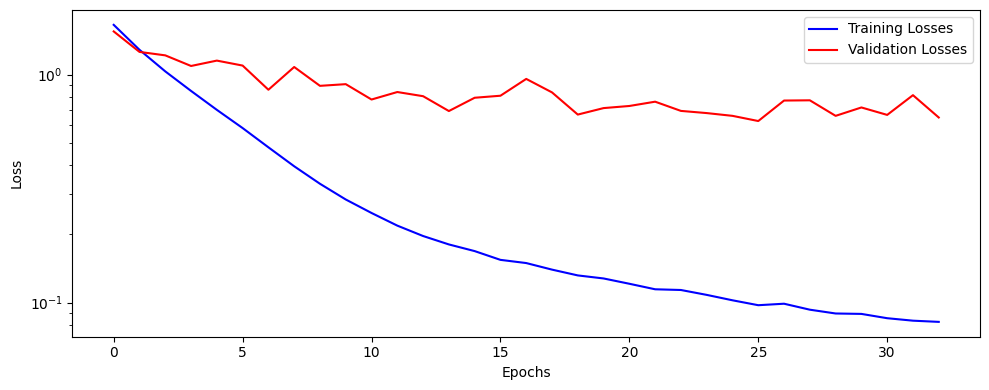

In [40]:
fig = sbs_custom.plot_losses()

In [41]:
sbs_custom.model_testing()

Total test samples checked: 5743
Test accuracy: tensor(85.2690, device='cuda:0')


In [42]:
torch.save({
    'model_state_dict': sbs_custom.best_model_weights
}, "checkpoint.pth")